In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import time

from sklearn.datasets import make_moons

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
X, y = make_moons(
    
    n_samples=2000,
    
    noise=0.25,
    
    random_state=42
)

print(X.shape)

(2000, 2)


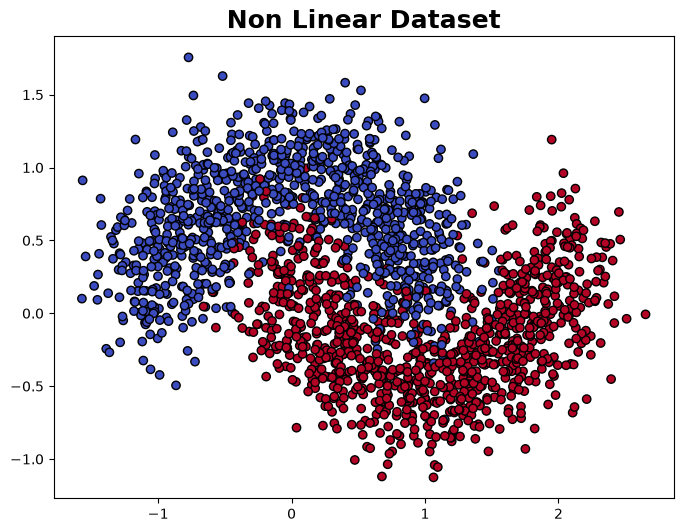

In [3]:
plt.figure(figsize=(8,6))

plt.scatter(
    
    X[:,0],
    
    X[:,1],
    
    c=y,
    
    cmap="coolwarm",
    
    edgecolors="black"
)

plt.title(
    
    "Non Linear Dataset",
    
    fontsize=18,
    
    fontweight="bold"
)

plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    
    X,
    
    y,
    
    test_size=0.3,
    
    random_state=42
)

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [6]:
kernels = {
    
    "Linear":
    SVC(kernel="linear"),
    
    "Polynomial":
    SVC(kernel="poly",
        degree=3),
    
    "RBF":
    SVC(kernel="rbf"),
    
    "Sigmoid":
    SVC(kernel="sigmoid")
}

In [7]:
results = []

trained_models = {}

In [8]:
for name, model in kernels.items():
    
    start_train = time.time()
    
    model.fit(
        
        X_train_scaled,
        
        y_train
    )
    
    train_time = time.time() - start_train
    
    
    start_pred = time.time()
    
    pred = model.predict(
        
        X_test_scaled
    )
    
    pred_time = time.time() - start_pred
    
    
    acc = accuracy_score(
        
        y_test,
        
        pred
    )
    
    prec = precision_score(
        
        y_test,
        
        pred
    )
    
    rec = recall_score(
        
        y_test,
        
        pred
    )
    
    f1 = f1_score(
        
        y_test,
        
        pred
    )
    
    
    results.append([
        
        name,
        
        acc,
        
        prec,
        
        rec,
        
        f1,
        
        train_time,
        
        pred_time,
        
        len(model.support_vectors_)
    ])
    
    
    trained_models[name] = model

In [9]:
comparison = pd.DataFrame(
    
    results,
    
    columns=[
        
        "Kernel",
        
        "Accuracy",
        
        "Precision",
        
        "Recall",
        
        "F1 Score",
        
        "Training Time",
        
        "Prediction Time",
        
        "Support Vectors"
    ]
)

comparison

,Kernel,Accuracy,Precision,Recall,F1 Score,Training Time,Prediction Time,Support Vectors
0,Linear,0.870000,0.877888,0.866450,0.872131,0.048054,0.010945,449
1,Polynomial,0.870000,0.875410,0.869707,0.872549,0.018511,0.005360,435
2,RBF,0.935000,0.949664,0.921824,0.935537,0.019446,0.022300,279
3,Sigmoid,0.693333,0.694006,0.716612,0.705128,0.039488,0.011115,473


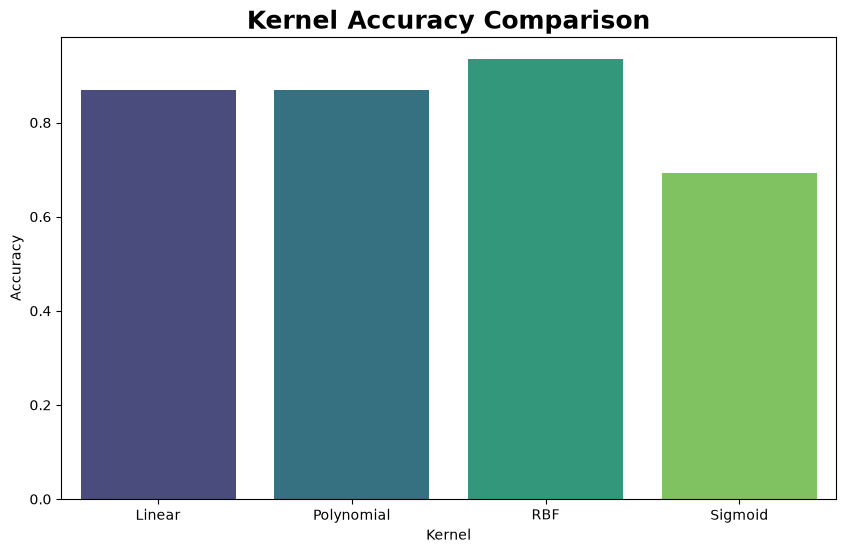

In [10]:
plt.figure(figsize=(10,6))

sns.barplot(
    
    data=comparison,
    
    x="Kernel",
    
    y="Accuracy",
    
    hue="Kernel",
    
    palette="viridis",
    
    legend=False
)

plt.title(
    
    "Kernel Accuracy Comparison",
    
    fontsize=18,
    
    fontweight="bold"
)

plt.show()

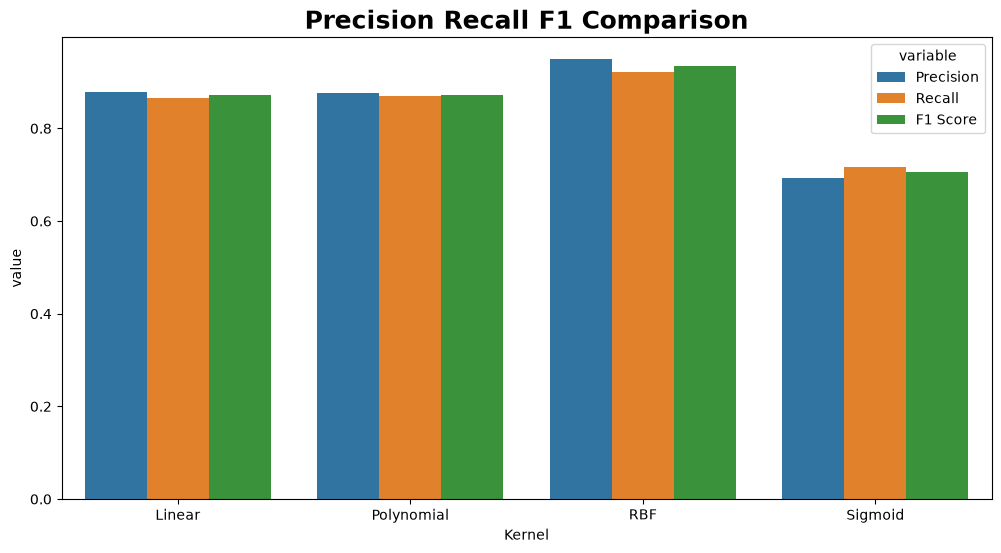

In [11]:
metrics = comparison.melt(
    
    id_vars="Kernel",
    
    value_vars=[
        
        "Precision",
        
        "Recall",
        
        "F1 Score"
    ]
)

plt.figure(figsize=(12,6))

sns.barplot(
    
    data=metrics,
    
    x="Kernel",
    
    y="value",
    
    hue="variable"
)

plt.title(
    
    "Precision Recall F1 Comparison",
    
    fontsize=18,
    
    fontweight="bold"
)

plt.show()

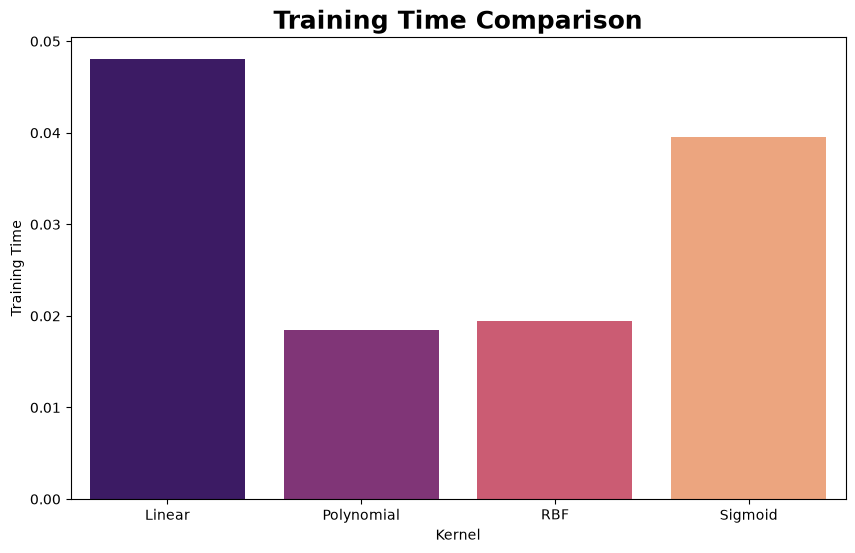

In [12]:
plt.figure(figsize=(10,6))

sns.barplot(
    
    data=comparison,
    
    x="Kernel",
    
    y="Training Time",
    
    hue="Kernel",
    
    palette="magma",
    
    legend=False
)

plt.title(
    
    "Training Time Comparison",
    
    fontsize=18,
    
    fontweight="bold"
)

plt.show()

In [13]:
def plot_decision_boundary(
    
    model,
    
    X,
    
    y,
    
    title
):
    
    x_min = X[:,0].min() - 1
    
    x_max = X[:,0].max() + 1
    
    y_min = X[:,1].min() - 1
    
    y_max = X[:,1].max() + 1
    
    
    xx, yy = np.meshgrid(
        
        np.linspace(
            x_min,
            x_max,
            500
        ),
        
        np.linspace(
            y_min,
            y_max,
            500
        )
    )
    
    
    Z = model.predict(
        
        np.c_[
            xx.ravel(),
            yy.ravel()
        ]
    )
    
    Z = Z.reshape(
        xx.shape
    )
    
    
    plt.contourf(
        
        xx,
        
        yy,
        
        Z,
        
        alpha=0.25,
        
        cmap="coolwarm"
    )
    
    
    plt.scatter(
        
        X[:,0],
        
        X[:,1],
        
        c=y,
        
        cmap="coolwarm",
        
        edgecolors="black",
        
        alpha=0.7
    )
    
    
    plt.scatter(
        
        model.support_vectors_[:,0],
        
        model.support_vectors_[:,1],
        
        s=150,
        
        facecolors="yellow",
        
        edgecolors="black",
        
        linewidth=2,
        
        label="Support Vectors"
    )
    
    
    plt.title(
        
        title,
        
        fontsize=14,
        
        fontweight="bold"
    )
    
    plt.legend()

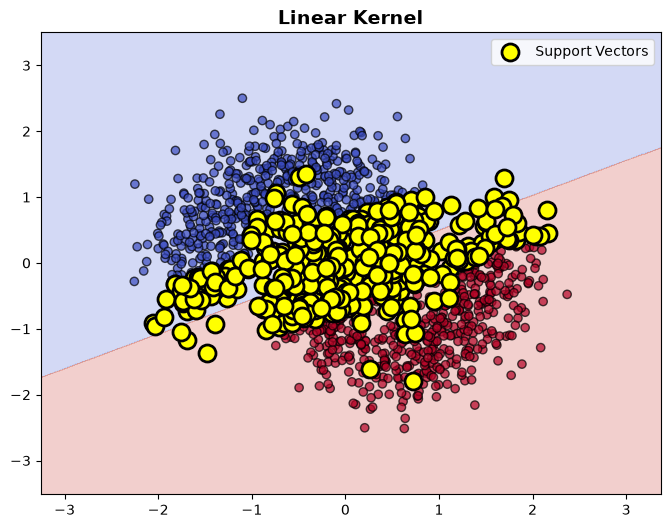

In [14]:
plt.figure(figsize=(8,6))

plot_decision_boundary(
    
    trained_models["Linear"],
    
    X_train_scaled,
    
    y_train,
    
    "Linear Kernel"
)

plt.show()

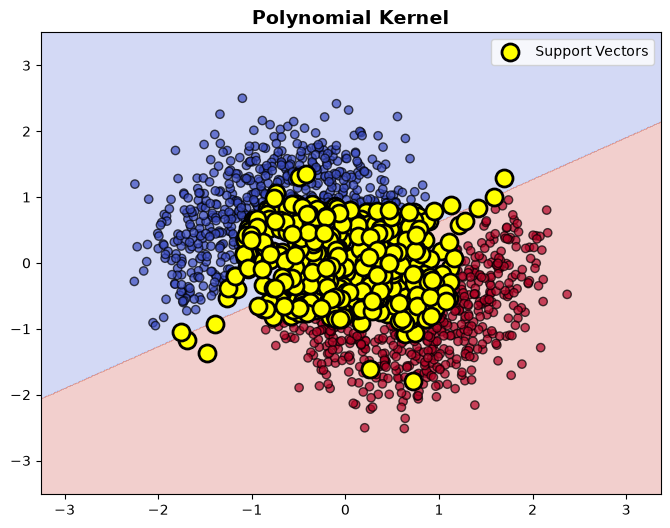

In [17]:
plt.figure(figsize=(8,6))

plot_decision_boundary(
    
    trained_models["Polynomial"],
    
    X_train_scaled,
    
    y_train,
    
    "Polynomial Kernel"
)

plt.show()

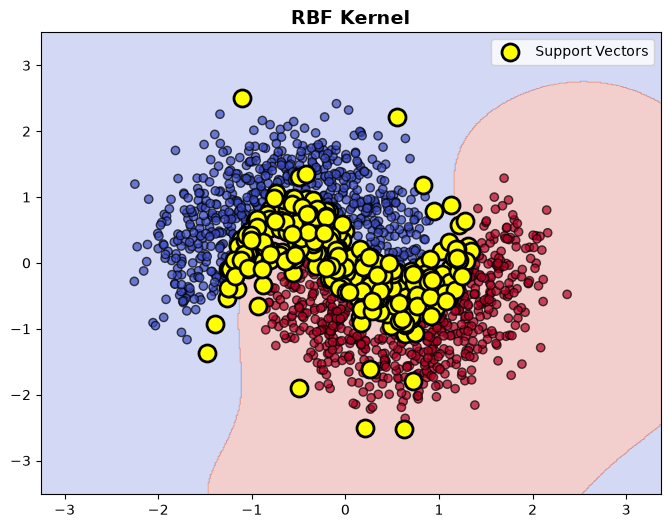

In [15]:
plt.figure(figsize=(8,6))

plot_decision_boundary(
    
    trained_models["RBF"],
    
    X_train_scaled,
    
    y_train,
    
    "RBF Kernel"
)

plt.show()

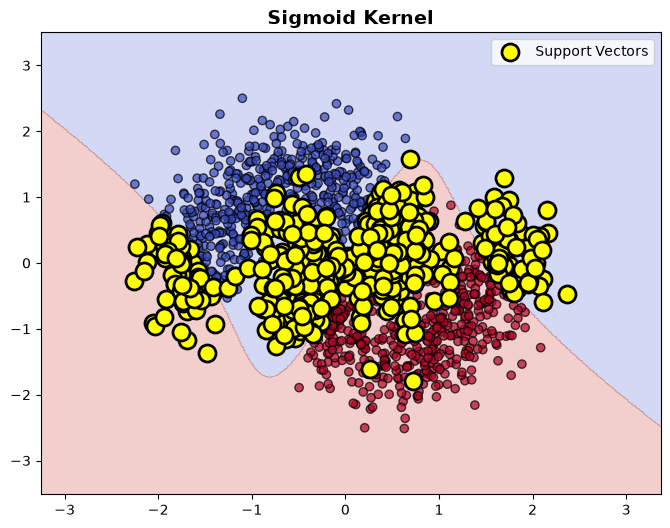

In [16]:
plt.figure(figsize=(8,6))

plot_decision_boundary(
    
    trained_models["Sigmoid"],
    
    X_train_scaled,
    
    y_train,
    
    "Sigmoid Kernel"
)

plt.show()

In [18]:
comparison = comparison.sort_values(
    
    by="Accuracy",
    
    ascending=False
)

comparison.style.background_gradient(
    
    cmap="YlGn"
)

,Kernel,Accuracy,Precision,Recall,F1 Score,Training Time,Prediction Time,Support Vectors
2,RBF,0.935000,0.949664,0.921824,0.935537,0.019446,0.022300,279
0,Linear,0.870000,0.877888,0.866450,0.872131,0.048054,0.010945,449
1,Polynomial,0.870000,0.875410,0.869707,0.872549,0.018511,0.005360,435
3,Sigmoid,0.693333,0.694006,0.716612,0.705128,0.039488,0.011115,473


C:\Users\engrf\AppData\Local\Temp\ipykernel_17452\396754696.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


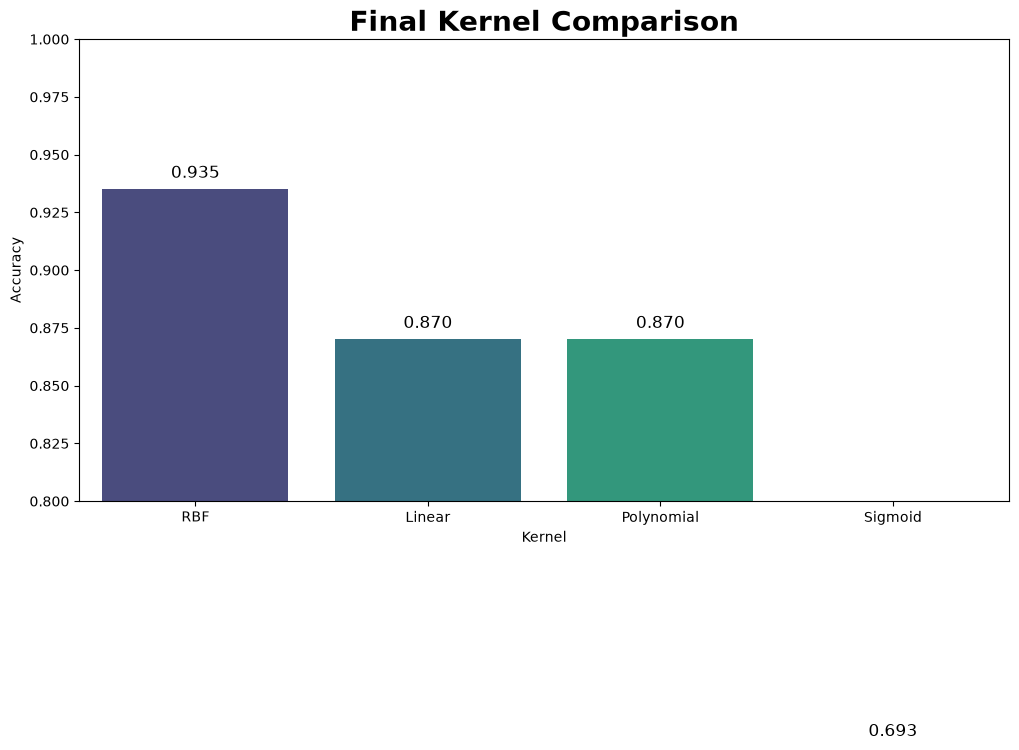

In [19]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=comparison,
    x="Kernel",
    y="Accuracy",
    palette="viridis"
)

for i,v in enumerate(comparison["Accuracy"]):

    plt.text(
        i,
        v+0.005,
        f"{v:.3f}",
        ha="center",
        fontsize=12
    )

plt.ylim(
    0.8,
    1.0
)

plt.title(
    "Final Kernel Comparison",
    fontsize=20,
    fontweight="bold"
)

plt.show()